In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

houses = pd.read_csv('data/bygningsbestand_2022.csv').set_index('byggeaar')
houses

,antall,varmepumpe,etterisolert,energi
byggeaar,,,,
1900,79505.0,0.0,0.0,22480.199109
1901,2407.0,0.0,0.0,22480.199109
1902,2407.0,0.0,0.0,22480.199109
1903,2407.0,0.0,0.0,22480.199109
1904,2407.0,0.0,0.0,22480.199109
...,...,...,...,...
2018,7683.3,0.0,0.0,18766.975225
2019,7683.3,0.0,0.0,18766.975225
2020,7683.3,0.0,0.0,18766.975225


In [99]:
projection_years = np.arange(2022, 2101)

demolition_rate = pd.Series(
    np.linspace(0.0011, 0.002, len(projection_years)), #1100/1e6 #about one million houses, then i just put that it increased to 0.002 as the houses get older
                index =projection_years,
    )

# Carbon intensity (kgCO2/kWh) — all electric
carbon_intensity = pd.Series(
    #np.linspace(0.242, 0.020, len(projection_years)),
    np.linspace(0.015, 0.010, len(projection_years)),
    index=projection_years,
)

hp_max = 0.35  #setting a max share of possible retrofits due to factors like a lot of houses already have a heat pump
is_max = 0.5
bo_max = 0.425

hp_inst_yr       =  10000.0
is_inst_yr        = 10000.0
bo_inst_yr        = 10000.0


hp_saving_heat = 0.50   # heat pump reduces heating energy by 50% conservate 50-80%
is_saving_heat =     0.25   # insulation reduces heating energy by 25% middle 20-30%
heating_share          = 0.67   # fraction of energy used for heating
hp_co2       = 7.87*1e3   # tCO2 per heat pump
is_co2    = 0.56*1e3   # tCO2 per insulation job

hp_saving = hp_saving_heat*heating_share
is_saving = is_saving_heat*heating_share
bo_saving = (1-(1-hp_saving_heat)*(1-is_saving_heat))*heating_share

print(hp_saving)
print(is_saving)
print(bo_saving)

0.335
0.1675
0.41875


In [100]:
house_stock = pd.DataFrame(0.0,
                           index=houses.index,
                           columns = projection_years)

energy = pd.DataFrame(0.0, index=projection_years, columns=['b', 'hp', 'is', 'bo'])
emmison =  pd.DataFrame(0.0, index=projection_years, columns=['b', 'hp', 'is', 'bo'])
install_emmison = pd.DataFrame(0.0, index=projection_years, columns=['b','hp', 'is', 'bo'])

adoption = pd.DataFrame(0.0, index=projection_years, columns=['hp', 'is', 'bo'])
share = pd.DataFrame(0.0, index=projection_years, columns=['hp', 'is', 'bo'])

hp_new = hp_inst_yr
is_new = is_inst_yr
bo_new = bo_inst_yr

house_stock.loc[:,2022] = houses['antall']

base_energy = house_stock.loc[:,2022]@houses['energi']
energy.loc[2022] = [
        base_energy,
        base_energy,
        base_energy,
        base_energy,
]

emmison.loc[2022] = energy.loc[2022]*carbon_intensity[2022] 

 


for yr in projection_years[1:]:

    house_stock.loc[:,yr] = house_stock.loc[:,yr-1]*(1-demolition_rate[yr]) 
    
    number_of_houses = house_stock.loc[:,yr].sum()

    if share.loc[yr-1,'hp'] > hp_max:
        hp_new = 0

    if share.loc[yr-1,'is'] > is_max:
        is_new = 0
    
    if share.loc[yr-1,'bo']  > bo_max:
        bo_new = 0

    adoption.loc[yr, 'hp'] = adoption.loc[yr-1, 'hp']*(1-demolition_rate[yr]) + hp_new
    adoption.loc[yr, 'is'] = adoption.loc[yr-1, 'is']*(1-demolition_rate[yr]) + is_new
    adoption.loc[yr, 'bo'] = adoption.loc[yr-1, 'bo']*(1-demolition_rate[yr]) + bo_new

    share.loc[yr, 'hp'] = adoption.loc[yr, 'hp']/number_of_houses
    share.loc[yr, 'is'] = adoption.loc[yr, 'is']/number_of_houses
    share.loc[yr, 'bo'] = adoption.loc[yr, 'bo']/number_of_houses

    base_energy = house_stock.loc[:,yr]@houses['energi']

    energy.loc[yr] = [
        base_energy,
        base_energy*(1-hp_saving*share.loc[yr,'hp']),
        base_energy*(1-is_saving*share.loc[yr,'is']),
        base_energy*(1-bo_saving*share.loc[yr,'bo']),
    ]

    install_emmison.loc[yr] = [
        0,
        hp_new*hp_co2,
        is_new*is_co2,
        bo_new*(hp_co2+is_co2)
    ]
        
        
    emmison.loc[yr] = energy.loc[yr]*carbon_intensity[yr] + install_emmison.loc[yr]

  
energy


#emmison.loc[2023,'b']-emmison.loc[2023,'hp']
#print(install_emmison.loc[2023, 'hp'])

,b,hp,is,bo
2022,2.987841e+10,2.987841e+10,2.987841e+10,2.987841e+10
2023,2.984520e+10,2.976761e+10,2.980640e+10,2.974821e+10
2024,2.981168e+10,2.965659e+10,2.973413e+10,2.961781e+10
2025,2.977786e+10,2.954535e+10,2.966160e+10,2.948722e+10
2026,2.974373e+10,2.943389e+10,2.958881e+10,2.935643e+10
...,...,...,...,...
2096,2.667236e+10,2.353532e+10,2.443128e+10,2.191689e+10
2097,2.661994e+10,2.348907e+10,2.438326e+10,2.187381e+10
2098,2.656731e+10,2.344263e+10,2.433506e+10,2.183057e+10
2099,2.651448e+10,2.339601e+10,2.428667e+10,2.178716e+10


Totalt utslipp:     		28.1 Mt CO₂
Spart med varmepumpe:     	 -1.3 Mt CO₂
Spart med etterisolering: 	 0.9 Mt CO₂
Spart med begge: 		 -1.4 Mt CO₂


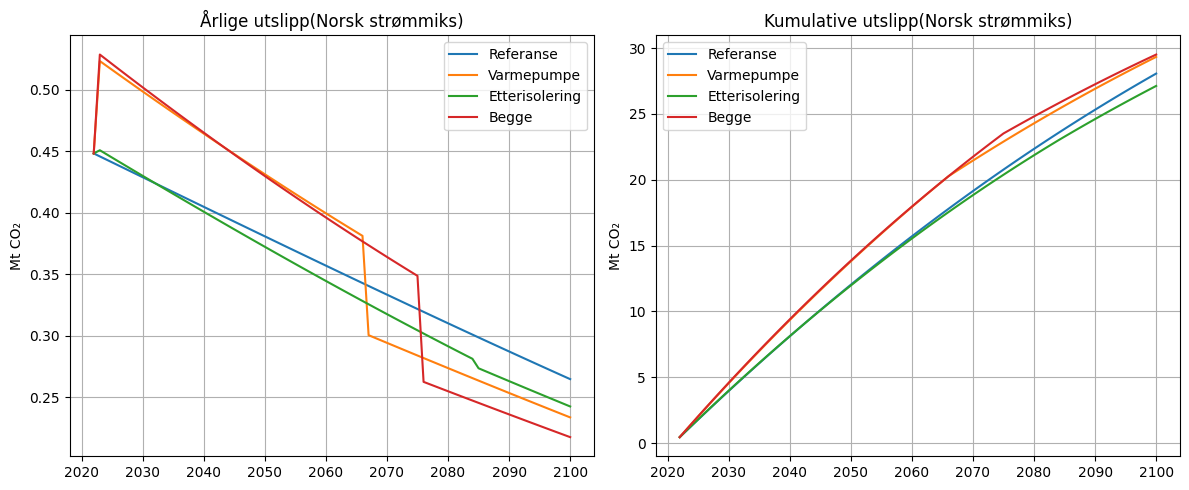

In [101]:
labels = ['Referanse', 'Varmepumpe', 'Etterisolering', 'Begge']

base_c = emmison['b'].cumsum()/1e9
heat_c = emmison['hp'].cumsum()/1e9
iso_c = emmison['is'].cumsum()/1e9
both_c = emmison['bo'].cumsum()/1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(projection_years, emmison['b']/1e9, label=labels[0])
ax1.plot(projection_years, emmison['hp']/1e9, label=labels[1])
ax1.plot(projection_years, emmison['is']/1e9, label=labels[2])
ax1.plot(projection_years, emmison['bo']/1e9, label=labels[3])
ax1.set_title('Årlige utslipp(Norsk strømmiks)')
ax1.set_ylabel('Mt CO₂')
ax1.legend()
ax1.grid()

ax2.plot(projection_years, base_c, label=labels[0])
ax2.plot(projection_years, heat_c, label=labels[1])
ax2.plot(projection_years, iso_c, label=labels[2])
ax2.plot(projection_years, both_c, label=labels[3])
ax2.set_title('Kumulative utslipp(Norsk strømmiks)')
ax2.set_ylabel('Mt CO₂')
ax2.legend()
ax2.grid()

plt.tight_layout()
print(f"Totalt utslipp:     \t\t{base_c.iloc[-1]:.1f} Mt CO₂")
print(f"Spart med varmepumpe:     \t {base_c.iloc[-1] - heat_c.iloc[-1]:.1f} Mt CO₂")
print(f"Spart med etterisolering: \t { base_c.iloc[-1] - iso_c.iloc[-1]:.1f} Mt CO₂")
print(f"Spart med begge: \t\t {base_c.iloc[-1] - both_c.iloc[-1]:.1f} Mt CO₂")

#plt.savefig('europeiskstrømmiks')

Totalt Strømforbruk:     	2,236 TWh
Spart med varmepumpe:     	  184 TWh
Spart med etterisolering: 	   110 TWh
Spart med begge: 		  256 TWh


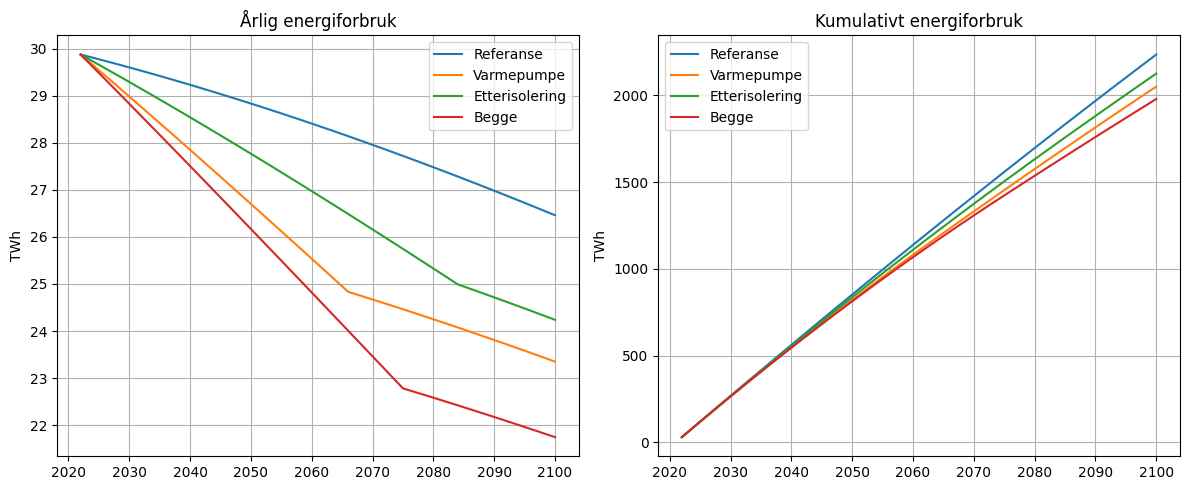

In [102]:
labels = ['Referanse', 'Varmepumpe', 'Etterisolering', 'Begge']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(projection_years, energy['b']/1e9, label=labels[0])
ax1.plot(projection_years, energy['hp']/1e9, label=labels[1])
ax1.plot(projection_years, energy['is']/1e9, label=labels[2])
ax1.plot(projection_years, energy['bo']/1e9, label=labels[3])
ax1.set_title('Årlig energiforbruk')
ax1.set_ylabel('TWh')
ax1.legend()
ax1.grid()

base_ce = energy['b'].cumsum()/1e9
heat_ce = energy['hp'].cumsum()/1e9
iso_ce = energy['is'].cumsum()/1e9
both_ce = energy['bo'].cumsum()/1e9

ax2.plot(projection_years, base_ce, label=labels[0])
ax2.plot(projection_years, heat_ce, label=labels[1])
ax2.plot(projection_years, iso_ce, label=labels[2])
ax2.plot(projection_years, both_ce, label=labels[3])
ax2.set_title('Kumulativt energiforbruk')
ax2.set_ylabel('TWh')
ax2.legend()
ax2.grid()

plt.tight_layout()

plt.savefig('strømforbruk')
print(f"Totalt Strømforbruk:     \t{base_ce.iloc[-1]:,.0f} TWh")
print(f"Spart med varmepumpe:     \t  {base_ce.iloc[-1] - heat_ce.iloc[-1]:,.0f} TWh")
print(f"Spart med etterisolering: \t   {base_ce.iloc[-1] - iso_ce.iloc[-1]:,.0f} TWh")
print(f"Spart med begge: \t\t  {base_ce.iloc[-1] - both_ce.iloc[-1]:,.0f} TWh")

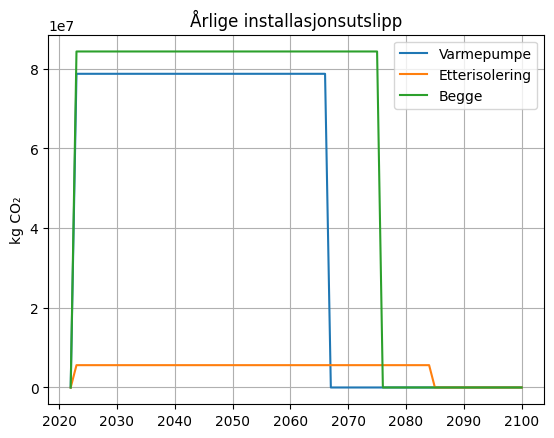

In [103]:
plt.plot(projection_years, install_emmison['hp'], label='Varmepumpe')
plt.plot(projection_years, install_emmison['is'], label='Etterisolering')
plt.plot(projection_years, install_emmison['bo'], label='Begge')
plt.title('Årlige installasjonsutslipp')
plt.ylabel('kg CO₂')
plt.legend()
plt.grid()

Installasjon varmepumpe:     3.5 Mt CO₂
Installasjon etterisolering: 0.3 Mt CO₂
Installasjon med begge:      4.5 Mt CO₂


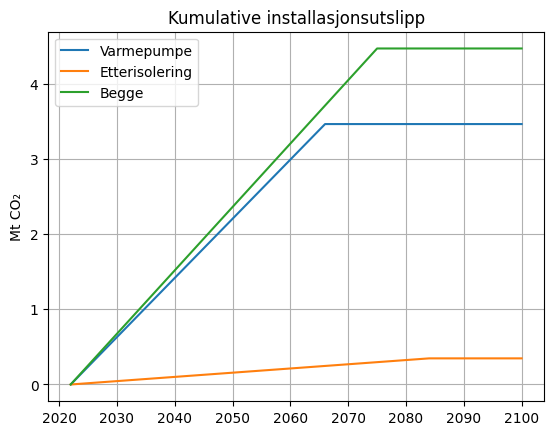

In [104]:
heat_cei = install_emmison['hp'].cumsum()/1e9
iso_cei = install_emmison['is'].cumsum()/1e9
both_cei = install_emmison['bo'].cumsum()/1e9

plt.plot(projection_years, heat_cei, label='Varmepumpe')
plt.plot(projection_years, iso_cei, label='Etterisolering')
plt.plot(projection_years, both_cei, label='Begge')
plt.title('Kumulative installasjonsutslipp')
plt.ylabel('Mt CO₂')
plt.legend()
plt.grid()

print(f"Installasjon varmepumpe:     {heat_cei.iloc[-1]:.1f} Mt CO₂")
print(f"Installasjon etterisolering: {iso_cei.iloc[-1]:.1f} Mt CO₂")
print(f"Installasjon med begge:      {both_cei.iloc[-1]:.1f} Mt CO₂")

plt.savefig('installqsjonsutslipp')